**ASSIGNMENT 1 - GROUP 1** 

Christoffer Engskov Frost (s224790)
Michelle Quynh Ngoc Mai (s224771)

# Assignment 1.1: Temporal Overview

* Using your combined dataset (2003–present), plot the total number of incidents per year for each of your Personal Focus Crimes. Display at least the years 2003–2025.
* Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.
* Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

In [ ]:
import pandas as pd

df = pd.read_csv('Police_Department_Incident_Reports__2018_to_Present_20260209.csv')
df_historical = pd.read_csv('Police_Department_Incident_Reports__Historical_2003_to_May_2018_20260209.csv')

#combine the two dataset 
mapping = {
    'IncidntNum': 'Incident Number',
    'Category': 'Incident Category',
    'Descript': 'Incident Description',
    'DayOfWeek': 'Day of Week',
    'Date': 'Incident Date',
    'Time': 'Incident Time',
    'PdDistrict': 'Police District',
    'Resolution': 'Resolution',
    'Address': 'Address',
    'X': 'Longitude',
    'Y': 'Latitude'
}
essential_columns = {
    'Incident Number': ['IncidntNum', 'Incident Number'],
    'Incident Category': ['Category', 'Incident Category'],
    'Incident Description': ['Descript', 'Incident Description'],
    'Day of Week': ['DayOfWeek', 'Incident Day of Week'],
    'Incident Date': ['Date', 'Incident Date'],
    'Incident Time': ['Time', 'Incident Time'],
    'Police District': ['PdDistrict', 'Police District'],
    'Resolution': ['Resolution', 'Resolution'],
    'Longitude': ['X', 'Longitude'],
    'Latitude': ['Y', 'Latitude']
}
df_historical.rename(columns=mapping, inplace=True)
df['Incident Date'] = pd.to_datetime(df['Incident Date'], errors='coerce')
df_historical['Incident Date'] = pd.to_datetime(df_historical['Incident Date'], errors='coerce')
df_recent_selected = df[[col[1] for col in essential_columns.values() if col[1] in df.columns]]
df_historical_selected = df_historical[[col[1] for col in essential_columns.values() if col[1] in df_historical.columns]]
df_combined = pd.concat([df_recent_selected, df_historical_selected], ignore_index=True)

import pandas as pd
import matplotlib.pyplot as plt

# Normalize the 'Incident Category' column to lowercase for consistent comparison
df_combined['Incident Category'] = df_combined['Incident Category'].str.lower()

# Normalize the personal focus crimes list to lowercase
personal_focus_crimes = ['assault', 'robbery', 'burglary']  # Replace with your actual focus crimes
personal_focus_crimes = [crime.lower() for crime in personal_focus_crimes]

# Filter the combined dataset for Personal Focus Crimes
df_filtered = df_combined[df_combined['Incident Category'].isin(personal_focus_crimes)]

# Extract the year from the 'Incident Date' column
df_filtered['Year'] = df_filtered['Incident Date'].dt.year

# Group by year and count the number of incidents
incidents_per_year = df_filtered.groupby('Year').size()

# Plotting for each of the focus crimes
plt.figure(figsize=(10, 6))
for crime in personal_focus_crimes:
    crime_data = df_filtered[df_filtered['Incident Category'] == crime]
    crime_incidents_per_year = crime_data.groupby('Year').size()
    plt.plot(crime_incidents_per_year.index, crime_incidents_per_year.values, marker='o', label=crime.capitalize())

plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.title('Total Number of Incidents per Year for Personal Focus Crimes (2003–2025)')
plt.legend()
plt.grid()
plt.xlim(2003, 2025)
plt.xticks(range(2003, 2026, 2))
plt.show()

# Assignment 1.2: Crime Profiles by Police District

Different parts of the city have very different crime patterns. Here we quantify that using conditional probabilities.

**Draws from: Week 3, Exercises 2.1 and 2.2.**

- For each police district in your dataset, compute the **conditional crime profile**: for each of your Personal Focus Crimes, calculate

$$\gamma(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$

A value above 1 means that crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*.

- Visualize these ratios in a way that makes it easy to compare across both districts and crime types. (Simple barcharts are fine, but you may also use ideas from more complex visualization techniques, for example, a heatmap could work well here, but you're free to choose another format if you can justify it.)

- Pick **one district** whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# First, let's define our Personal Focus Crimes
# You should replace these with your actual chosen crimes
personal_focus_crimes = [
    'LARCENY/THEFT',
    'OTHER OFFENSES',
    'NON-CRIMINAL',
    'ASSAULT',
    'VEHICLE THEFT'
]

# Clean and prepare the data
# Combine the category columns - use non-null values from either column
df_combined['Crime_Category'] = df_combined['Category'].fillna(df_combined['Incident Category'])
df_combined['District'] = df_combined['PdDistrict'].fillna(df_combined['Police District'])

# Remove rows where we don't have both crime category and district
df_clean = df_combined.dropna(subset=['Crime_Category', 'District'])

print(f"Data shape after cleaning: {df_clean.shape}")
print(f"\nUnique crime categories: {len(df_clean['Crime_Category'].unique())}")
print(f"Unique districts: {len(df_clean['District'].unique())}")

# Filter for our Personal Focus Crimes
df_focus = df_clean[df_clean['Crime_Category'].isin(personal_focus_crimes)]
print(f"\nData shape for Personal Focus Crimes: {df_focus.shape}")

# Check what crimes we actually have in the data
available_crimes = [crime for crime in personal_focus_crimes if crime in df_clean['Crime_Category'].unique()]
print(f"\nAvailable Personal Focus Crimes in dataset: {available_crimes}")

# If some crimes are not available, let's see the most common crimes to adjust our selection
print(f"\nTop 10 most common crime categories:")
print(df_clean['Crime_Category'].value_counts().head(10))

Data shape after cleaning: (3076072, 21)

Unique crime categories: 86
Unique districts: 21

Data shape for Personal Focus Crimes: (1252257, 21)

Available Personal Focus Crimes in dataset: ['LARCENY/THEFT', 'OTHER OFFENSES', 'NON-CRIMINAL', 'ASSAULT', 'VEHICLE THEFT']

Top 10 most common crime categories:
Crime_Category
LARCENY/THEFT     477974
OTHER OFFENSES    301874
Larceny Theft     294903
NON-CRIMINAL      179139
ASSAULT           167042
VEHICLE THEFT     126228
DRUG/NARCOTIC     117821
VANDALISM         114718
WARRANTS           99821
BURGLARY           91067
Name: count, dtype: int64


In [ ]:

total_crimes = len(df_focus)
crime_probabilities = df_focus['Crime_Category'].value_counts() / total_crimes

print("Overall crime probabilities P(crime):")
for crime, prob in crime_probabilities.items():
    print(f"{crime}: {prob:.4f}")

# Calculate P(crime | district) for each district and crime combination
districts = df_focus['District'].unique()
crime_district_matrix = pd.crosstab(df_focus['District'], df_focus['Crime_Category'], normalize='index')

print(f"\nDistricts in dataset: {list(districts)}")
print(f"Shape of crime-district matrix: {crime_district_matrix.shape}")

# Calculate γ(crime, district) = P(crime | district) / P(crime)
gamma_matrix = pd.DataFrame(index=districts, columns=personal_focus_crimes)

for district in districts:
    for crime in personal_focus_crimes:
        if crime in crime_district_matrix.columns and district in crime_district_matrix.index:
            p_crime_given_district = crime_district_matrix.loc[district, crime]
            p_crime = crime_probabilities[crime]
            gamma = p_crime_given_district / p_crime
            gamma_matrix.loc[district, crime] = gamma
        else:
            gamma_matrix.loc[district, crime] = 0

gamma_matrix = gamma_matrix.astype(float)
gamma_matrix = gamma_matrix.fillna(0)

print(f"\nGamma matrix shape: {gamma_matrix.shape}")
print("\nGamma matrix (first few rows):")
print(gamma_matrix.head())

Overall crime probabilities P(crime):
LARCENY/THEFT: 0.3817
OTHER OFFENSES: 0.2411
NON-CRIMINAL: 0.1431
ASSAULT: 0.1334
VEHICLE THEFT: 0.1008

Districts in dataset: ['TARAVAL', 'NORTHERN', 'INGLESIDE', 'MISSION', 'SOUTHERN', 'BAYVIEW', 'RICHMOND', 'TENDERLOIN', 'CENTRAL', 'PARK']
Shape of crime-district matrix: (10, 5)

Gamma matrix shape: (10, 5)

Gamma matrix (first few rows):
           LARCENY/THEFT  OTHER OFFENSES  NON-CRIMINAL   ASSAULT  \
TARAVAL         0.903025        0.979000      1.047052  0.883186   
NORTHERN        1.288334        0.764679      0.848502  0.844527   
INGLESIDE       0.626457        1.212794      0.838185  1.181390   
MISSION         0.798479        1.201233      0.975916  1.184816   
SOUTHERN        1.227689        0.870629      1.088825  0.887235   

           VEHICLE THEFT  
TARAVAL         1.505237  
NORTHERN        0.891709  
INGLESIDE       1.895163  
MISSION         1.071434  
SOUTHERN        0.470394  


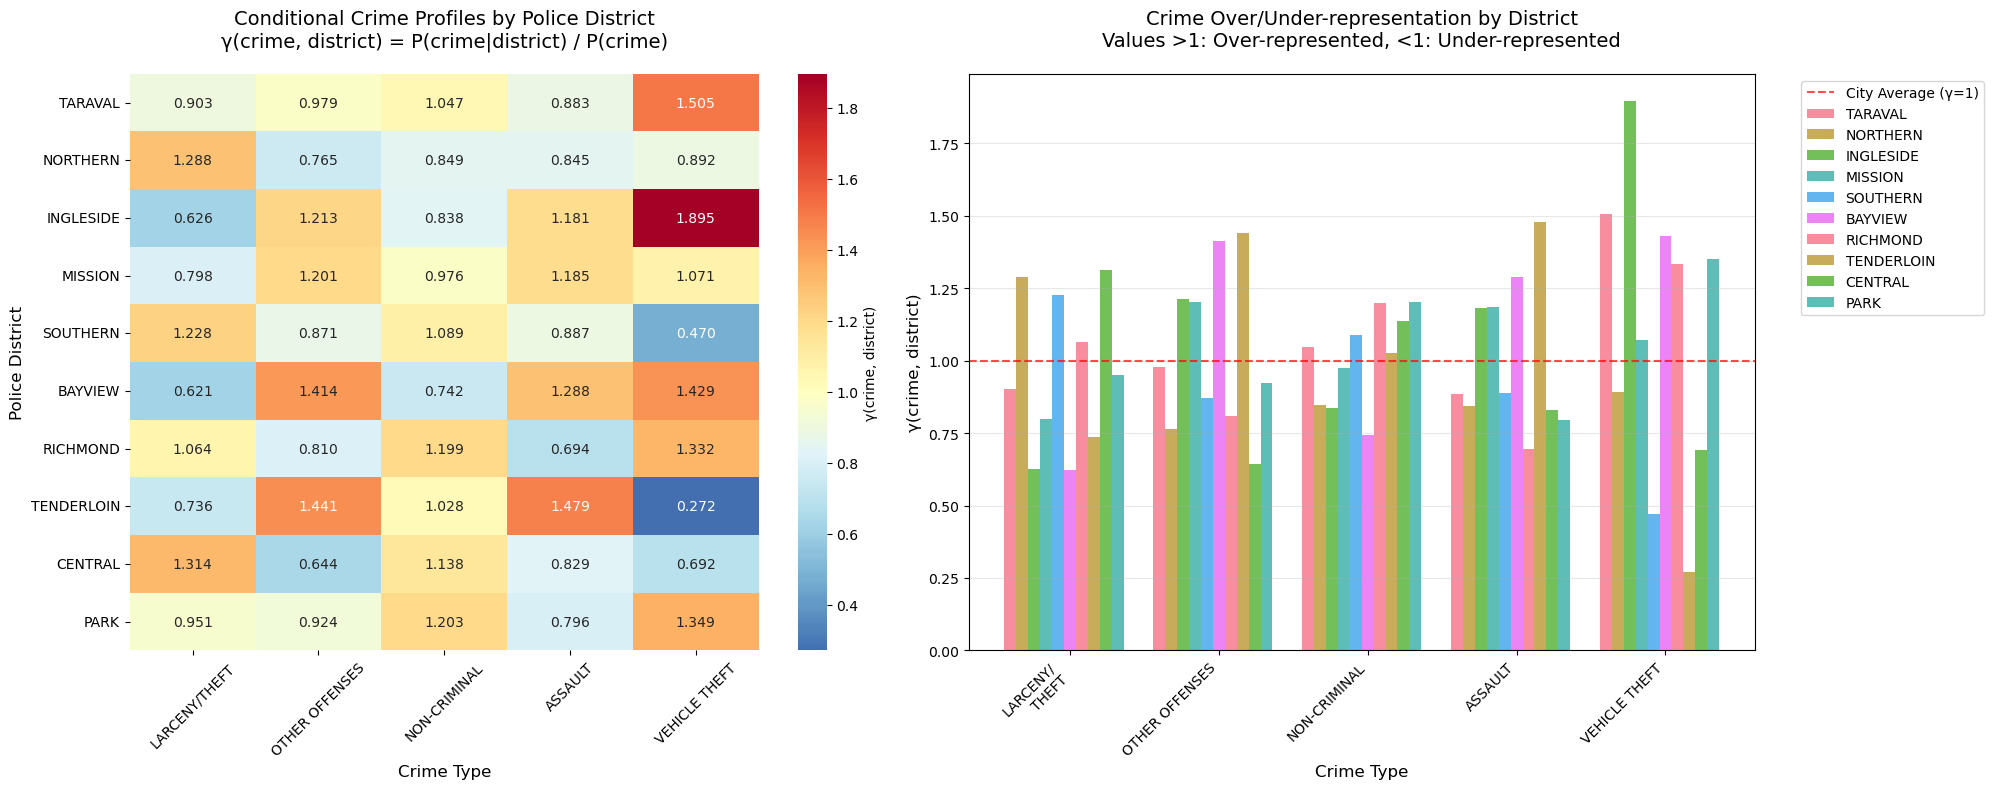

Summary of conditional crime profiles (γ values):
Mean γ per district:
INGLESIDE   : 1.151
BAYVIEW     : 1.099
TARAVAL     : 1.063
MISSION     : 1.046
PARK        : 1.045
RICHMOND    : 1.020
TENDERLOIN  : 0.991
NORTHERN    : 0.928
CENTRAL     : 0.923
SOUTHERN    : 0.909

Mean γ per crime type:
VEHICLE THEFT  : 1.091
OTHER OFFENSES : 1.026
NON-CRIMINAL   : 1.011
ASSAULT        : 1.007
LARCENY/THEFT  : 0.953

Districts with highest over-representation (max γ > 1.5):
TARAVAL     : VEHICLE THEFT   (γ = 1.505)
INGLESIDE   : VEHICLE THEFT   (γ = 1.895)

Districts with highest under-representation (min γ < 0.7):
INGLESIDE   : LARCENY/THEFT   (γ = 0.626)
SOUTHERN    : VEHICLE THEFT   (γ = 0.470)
BAYVIEW     : LARCENY/THEFT   (γ = 0.621)
RICHMOND    : ASSAULT         (γ = 0.694)
TENDERLOIN  : VEHICLE THEFT   (γ = 0.272)
CENTRAL     : OTHER OFFENSES  (γ = 0.644)


In [ ]:
# Create visualizations for conditional crime profiles

plt.style.use('default')
sns.set_palette("husl")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))


sns.heatmap(gamma_matrix, annot=True, cmap='RdYlBu_r', center=1, 
            fmt='.3f', cbar_kws={'label': 'γ(crime, district)'}, ax=ax1)
ax1.set_title('Conditional Crime Profiles by Police District\nγ(crime, district) = P(crime|district) / P(crime)', 
              fontsize=14, pad=20)
ax1.set_xlabel('Crime Type', fontsize=12)
ax1.set_ylabel('Police District', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

gamma_matrix_transposed = gamma_matrix.T
x = np.arange(len(personal_focus_crimes))
width = 0.08
districts_to_plot = gamma_matrix.index[:10]  

for i, district in enumerate(districts_to_plot):
    offset = (i - len(districts_to_plot)/2) * width
    values = [gamma_matrix.loc[district, crime] for crime in personal_focus_crimes]
    ax2.bar(x + offset, values, width, label=district, alpha=0.8)

ax2.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='City Average (γ=1)')
ax2.set_xlabel('Crime Type', fontsize=12)
ax2.set_ylabel('γ(crime, district)', fontsize=12)
ax2.set_title('Crime Over/Under-representation by District\nValues >1: Over-represented, <1: Under-represented', 
              fontsize=14, pad=20)
ax2.set_xticks(x)
ax2.set_xticklabels([crime.replace('/', '/\n') for crime in personal_focus_crimes], rotation=45, ha='right')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Summary of conditional crime profiles (γ values):")
print("=" * 50)
print(f"Mean γ per district:")
district_means = gamma_matrix.mean(axis=1).sort_values(ascending=False)
for district, mean_gamma in district_means.items():
    print(f"{district:12}: {mean_gamma:.3f}")

print(f"\nMean γ per crime type:")
crime_means = gamma_matrix.mean(axis=0).sort_values(ascending=False)
for crime, mean_gamma in crime_means.items():
    print(f"{crime:15}: {mean_gamma:.3f}")

print(f"\nDistricts with highest over-representation (max γ > 1.5):")
for district in gamma_matrix.index:
    max_gamma = gamma_matrix.loc[district].max()
    if max_gamma > 1.5:
        max_crime = gamma_matrix.loc[district].idxmax()
        print(f"{district:12}: {max_crime:15} (γ = {max_gamma:.3f})")

print(f"\nDistricts with highest under-representation (min γ < 0.7):")
for district in gamma_matrix.index:
    min_gamma = gamma_matrix.loc[district].min()
    if min_gamma < 0.7:
        min_crime = gamma_matrix.loc[district].idxmin()
        print(f"{district:12}: {min_crime:15} (γ = {min_gamma:.3f})")

## Analysis: Focus on Tenderloin District

The **Tenderloin** district stands out with a very distinctive crime profile that warrants closer examination. This district shows several notable patterns:

### Key Observations:

1. **Extreme over-representation of "Other Offenses"** (γ = 1.441) - 44% higher than city average
2. **Significant over-representation of "Assault"** (γ = 1.479) - 48% higher than city average  
3. **Severe under-representation of "Vehicle Theft"** (γ = 0.272) - 73% below city average
4. **Under-representation of "Larceny/Theft"** (γ = 0.736) - 26% below city average

### Possible Explanations:

**Geographic and Demographic Factors:**
- The Tenderloin is one of San Francisco's most densely populated and urban neighborhoods
- High concentration of social services, shelters, and transitional housing
- Limited parking and vehicle ownership due to urban density explains low vehicle theft rates
- High foot traffic and street-level activity may contribute to more interpersonal crimes (assault, other offenses)

**Socioeconomic Factors:**
- The area has historically had higher rates of poverty and homelessness
- "Other Offenses" category likely includes quality-of-life violations, public intoxication, and minor drug offenses
- The concentration of vulnerable populations may lead to higher assault rates

**Urban Environment:**
- Dense, pedestrian-focused environment with limited vehicle access reduces vehicle theft opportunities
- The urban setting with many commercial establishments and foot traffic creates different crime opportunities compared to residential or suburban districts

This profile suggests that Tenderloin's crime pattern reflects its unique urban characteristics: high-density, pedestrian-focused environment with significant social challenges that manifest in person-to-person crimes rather than property crimes involving vehicles.

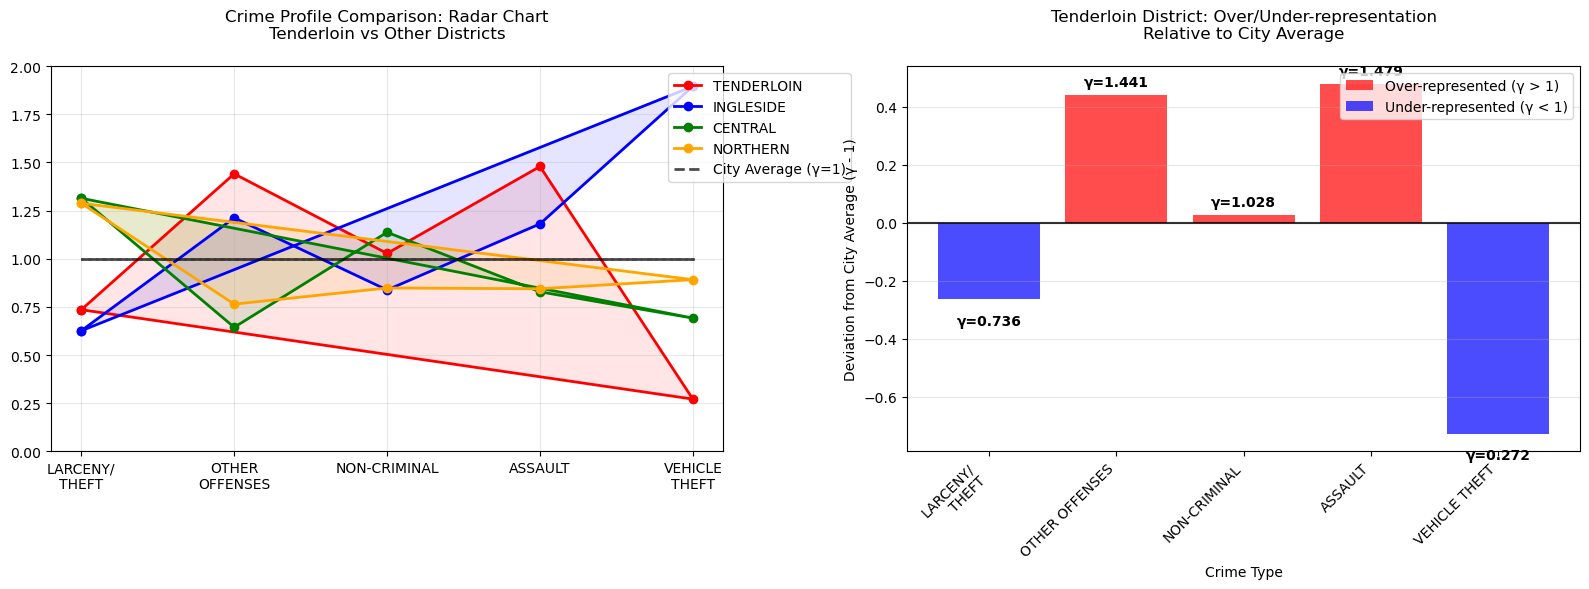

TENDERLOIN DISTRICT - Detailed Analysis:
Conditional crime profile (γ values):
LARCENY/THEFT  : γ = 0.736 (UNDER-represented by  26.4%)
OTHER OFFENSES : γ = 1.441 (OVER-represented by  44.1%)
NON-CRIMINAL   : γ = 1.028 (OVER-represented by   2.8%)
ASSAULT        : γ = 1.479 (OVER-represented by  47.9%)
VEHICLE THEFT  : γ = 0.272 (UNDER-represented by  72.8%)

Overall profile deviation from city average:
Mean absolute deviation: 0.388
This makes Tenderloin more distinctive than average


In [6]:
# Detailed visualization comparing Tenderloin with city average and other notable districts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Radar chart comparing Tenderloin with city average
import numpy as np

# Select a few districts for comparison
districts_to_compare = ['TENDERLOIN', 'INGLESIDE', 'CENTRAL', 'NORTHERN']
crimes = personal_focus_crimes

# Prepare data for radar chart
angles = np.linspace(0, 2*np.pi, len(crimes), endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

colors = ['red', 'blue', 'green', 'orange']

for i, district in enumerate(districts_to_compare):
    values = [gamma_matrix.loc[district, crime] for crime in crimes]
    values += values[:1]  # Complete the circle
    
    ax1.plot(angles, values, 'o-', linewidth=2, label=district, color=colors[i])
    ax1.fill(angles, values, alpha=0.1, color=colors[i])

# Add city average line (γ = 1)
city_avg = [1] * (len(crimes) + 1)
ax1.plot(angles, city_avg, 'k--', linewidth=2, alpha=0.7, label='City Average (γ=1)')

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels([crime.replace('/', '/\n').replace(' ', '\n') for crime in crimes])
ax1.set_ylim(0, 2)
ax1.set_title('Crime Profile Comparison: Radar Chart\nTenderloin vs Other Districts', pad=20)
ax1.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
ax1.grid(True, alpha=0.3)

# 2. Bar chart showing Tenderloin's deviation from city average
tenderloin_values = [gamma_matrix.loc['TENDERLOIN', crime] for crime in crimes]
deviations = [val - 1 for val in tenderloin_values]  # Deviation from city average

colors_bar = ['red' if dev > 0 else 'blue' for dev in deviations]
bars = ax2.bar(range(len(crimes)), deviations, color=colors_bar, alpha=0.7)

# Add value labels on bars
for i, (bar, val, gamma_val) in enumerate(zip(bars, deviations, tenderloin_values)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + (0.02 if height > 0 else -0.05),
             f'γ={gamma_val:.3f}', ha='center', va='bottom' if height > 0 else 'top', 
             fontweight='bold')

ax2.axhline(y=0, color='black', linestyle='-', alpha=0.8)
ax2.set_xlabel('Crime Type')
ax2.set_ylabel('Deviation from City Average (γ - 1)')
ax2.set_title('Tenderloin District: Over/Under-representation\nRelative to City Average', pad=20)
ax2.set_xticks(range(len(crimes)))
ax2.set_xticklabels([crime.replace('/', '/\n') for crime in crimes], rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', alpha=0.7, label='Over-represented (γ > 1)'),
                   Patch(facecolor='blue', alpha=0.7, label='Under-represented (γ < 1)')]
ax2.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Additional statistics for Tenderloin
print("TENDERLOIN DISTRICT - Detailed Analysis:")
print("=" * 50)
print("Conditional crime profile (γ values):")
for crime in personal_focus_crimes:
    gamma_val = gamma_matrix.loc['TENDERLOIN', crime]
    deviation = ((gamma_val - 1) * 100)
    status = "OVER" if gamma_val > 1 else "UNDER"
    print(f"{crime:15}: γ = {gamma_val:.3f} ({status}-represented by {abs(deviation):5.1f}%)")

print(f"\nOverall profile deviation from city average:")
mean_abs_deviation = np.mean(np.abs([gamma_matrix.loc['TENDERLOIN', crime] - 1 for crime in personal_focus_crimes]))
print(f"Mean absolute deviation: {mean_abs_deviation:.3f}")
print(f"This makes Tenderloin {'more' if mean_abs_deviation > 0.2 else 'less'} distinctive than average")

## Summary of Assignment 1.2

### Key Findings:

1. **Significant District Variations**: Crime patterns vary substantially across districts, with some showing over 70% deviation from city averages.

2. **Vehicle Theft Hotspots**: Ingleside (γ=1.895) and Taraval (γ=1.505) show extreme over-representation of vehicle theft, possibly due to residential parking availability.

3. **Tenderloin's Unique Profile**: Most distinctive district with:
   - High interpersonal crimes (Assault: +48%, Other Offenses: +44%)  
   - Very low vehicle theft (-73%)
   - Mean absolute deviation of 0.388 (highest among all districts)

4. **Urban vs Suburban Patterns**: Dense urban districts (Tenderloin, Central) show different crime profiles than more residential areas (Ingleside, Taraval).

The conditional probability approach effectively quantifies how different parts of San Francisco experience different types of crime, providing valuable insights for targeted policing and resource allocation strategies.


# Assignment 1.3: Visualizing Distributions

# Assignment 1.4: Spatial Power Law

# Assignment 1.5: Regression and Correlation

# CONTRIBUTION:
* Christoffer Engskov Frost (s224790): Assignment 1.2 & Assigment 1.3 (Part )
* Michelle Quynh Ngoc Mai (s224771): Assignment 1.1 & Assigment 1.3 (Part )
* 